In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

# Обработка данных

## Выгрузка df

In [75]:
df_raw = pd.read_csv(r'C:/credit_scoring_eng.csv')
df = df_raw.copy()
print(df.head(5))

   children  days_employed  dob_years            education  education_id  \
0         1   -8437.673028         42    bachelor's degree             0   
1         1   -4024.803754         36  secondary education             1   
2         0   -5623.422610         33  Secondary Education             1   
3         3   -4124.747207         32  secondary education             1   
4         0  340266.072047         53  secondary education             1   

       family_status  family_status_id gender income_type  debt  total_income  \
0            married                 0      F    employee     0     40620.102   
1            married                 0      F    employee     0     17932.802   
2            married                 0      M    employee     0     23341.752   
3            married                 0      M    employee     0     42820.568   
4  civil partnership                 1      F     retiree     0     25378.572   

                   purpose  
0    purchase of the house 

## Пропущенные значения

In [76]:
#Считаем пропущенные для каждого столбца

print(df.info())
print()
print(df.isna()[['days_employed','total_income']].sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  object 
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  object 
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  object 
 8   income_type       21525 non-null  object 
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB
None

days_employed    2174
total_income     2174
dtype: int64


In [77]:
print(df[df.isna().any(axis=1)][0:10])

    children  days_employed  dob_years            education  education_id  \
12         0            NaN         65  secondary education             1   
26         0            NaN         41  secondary education             1   
29         0            NaN         63  secondary education             1   
41         0            NaN         50  secondary education             1   
55         0            NaN         54  secondary education             1   
65         0            NaN         21  secondary education             1   
67         0            NaN         52    bachelor's degree             0   
72         1            NaN         32    bachelor's degree             0   
82         2            NaN         50    bachelor's degree             0   
83         0            NaN         52  secondary education             1   

        family_status  family_status_id gender    income_type  debt  \
12  civil partnership                 1      M        retiree     0   
26        

In [78]:
# Считаем пропущенные по категориям

for i in df['education'].unique():
    data_i = df[df['education']==i]['days_employed']
    data_missing = 1-data_i.count() / len(data_i)
    if data_missing>0.1:
        print(f'Для {i} упущено {data_missing:.1%} процентов данных days_employed')
print()
for i in df['income_type'].unique():
    data_i = df[df['income_type']==i]['total_income']
    data_missing = 1-data_i.count() / len(data_i)
    if data_missing>0.1:
        print(f'Для {i} упущено {data_missing:.1%} процентов данных total income')

Для bachelor's degree упущено 10.5% процентов данных days_employed
Для secondary education упущено 10.2% процентов данных days_employed
Для SOME COLLEGE упущено 24.1% процентов данных days_employed
Для Some College упущено 14.9% процентов данных days_employed

Для retiree упущено 10.7% процентов данных total income
Для civil servant упущено 10.1% процентов данных total income
Для entrepreneur упущено 50.0% процентов данных total income


In [79]:
#Смотрим средние значения по категориям

for i in df['education'].unique():
    data_i = df[df['education']==i]['days_employed']
    mean_value = round(data_i.agg('mean'))
    print(f'Для {i} средний days employed {mean_value}')
print()
for i in df['income_type'].unique():
    data_i = df[df['income_type']==i]['total_income']
    mean_value = round(data_i.agg('mean'))
    print(f'Для {i} средний total income {mean_value}')

Для bachelor's degree средний days employed 38720
Для secondary education средний days employed 72325
Для Secondary Education средний days employed 81647
Для SECONDARY EDUCATION средний days employed 67942
Для BACHELOR'S DEGREE средний days employed 40038
Для some college средний days employed 17138
Для primary education средний days employed 127235
Для Bachelor's Degree средний days employed 29661
Для SOME COLLEGE средний days employed 14778
Для Some College средний days employed 27799
Для PRIMARY EDUCATION средний days employed 158500
Для Primary Education средний days employed 102825
Для Graduate Degree средний days employed 337585
Для GRADUATE DEGREE средний days employed -409
Для graduate degree средний days employed 90651

Для employee средний total income 25821
Для retiree средний total income 21940
Для business средний total income 32387
Для civil servant средний total income 27344
Для unemployed средний total income 21014
Для entrepreneur средний total income 79866
Для student

In [80]:
#Заполняем данные

df['total_income'] = df['total_income'].fillna(df.groupby(['education', 'income_type'])['total_income'].transform('mean'))

df['days_employed'] = df['days_employed'].abs()
df['days_employed'] = df['days_employed'].fillna(0)

In [81]:
#Проверяем заполнение

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     21525 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  object 
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  object 
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  object 
 8   income_type       21525 non-null  object 
 9   debt              21525 non-null  int64  
 10  total_income      21525 non-null  float64
 11  purpose           21525 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB
None


Уточнение по заполнению:
- Решили заполнять, так пропущено значения более чем 10% в зависимости от категории.
- Заполняли средними значениями, так как есть разница между средними значнеиями в зависимости от категории/

## Дубликаты

In [82]:
#Смотрим уникальные значения, и группируем, если по смыслу повторяются

df.nunique()
df.columns

for col in ['children', 'education', 'family_status', 'family_status_id', 'gender', 'income_type', 'purpose']:
    print(f'{col}, {df[col].unique()}')

df['gender'] = df['gender'].replace('XNA', None)
df['children'] = df['children'].replace(-1, 0)
df['education'] = df['education'].str.lower()
df['purpose'] = df['purpose'].replace({
    'purchase of the house for my family':'housing',
    'purchase of my own house':'housing',
    'buying my own car':'car purchase',
    'purchase of a car':'car purchase',
    'to buy a car':'car purchase',
    'to own a car':'car purchase',
    'cars':'cars purchase',
    'car':'cars purchase',
    'buying a second-hand car':'second hand car purchase',
    'second-hand car purchase':'second hand car purchase',
    'to become educated':'education',
    'getting an education':'education',
    'getting higher education':'education', 
    'profile education':'education',
    'university education':'education',
    'going to university':'education',
    'to get a supplementary education':'supplementary education',
    'buy real estate':'housing transactions',
    'buy commercial real estate':'housing transactions',
    'buy residential real estate':'housing transactions',
    'transactions with commercial real estate':'housing transactions',
    'real estate transactions':'housing transactions',
    'buying property for renting out':'housing transactions',
    'transactions with my real estate':'housing transactions',
    'purchase of the house':'housing transactions',
    'building a property':'building a property',
    'building a real estate':'building a property',
    'construction of own property':'building a property',
    'to have a wedding':'wedding ceremony',
    'having a wedding':'wedding ceremony',
})

children, [ 1  0  3  2 -1  4 20  5]
education, ["bachelor's degree" 'secondary education' 'Secondary Education'
 'SECONDARY EDUCATION' "BACHELOR'S DEGREE" 'some college'
 'primary education' "Bachelor's Degree" 'SOME COLLEGE' 'Some College'
 'PRIMARY EDUCATION' 'Primary Education' 'Graduate Degree'
 'GRADUATE DEGREE' 'graduate degree']
family_status, ['married' 'civil partnership' 'widow / widower' 'divorced' 'unmarried']
family_status_id, [0 1 2 3 4]
gender, ['F' 'M' 'XNA']
income_type, ['employee' 'retiree' 'business' 'civil servant' 'unemployed'
 'entrepreneur' 'student' 'paternity / maternity leave']
purpose, ['purchase of the house' 'car purchase' 'supplementary education'
 'to have a wedding' 'housing transactions' 'education' 'having a wedding'
 'purchase of the house for my family' 'buy real estate'
 'buy commercial real estate' 'buy residential real estate'
 'construction of own property' 'property' 'building a property'
 'buying a second-hand car' 'buying my own car'
 'transa

## Выбросы

In [83]:
#Смотрим minmax и среднее по интересующим категориям

print(df['total_income'].agg(['min', 'max', 'mean']))
print()
print(df['dob_years'].agg(['min', 'max', 'mean']))
print()
print(df['children'].agg(['min', 'max', 'mean']))

min       3306.762000
max     362496.645000
mean     26792.847918
Name: total_income, dtype: float64

min      0.00000
max     75.00000
mean    43.29338
Name: dob_years, dtype: float64

min      0.000000
max     20.000000
mean     0.541092
Name: children, dtype: float64


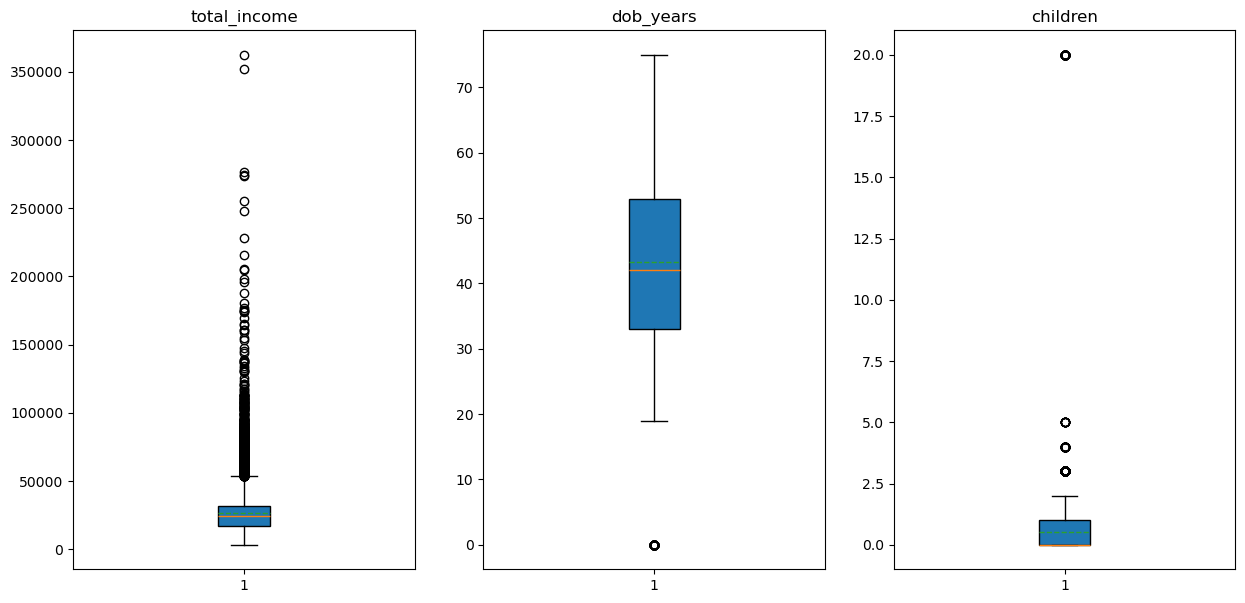

In [84]:
#Визуализация для оценки выбросов

fig, axes = plt.subplots(1, 3, figsize=(15, 7))

axes[0].boxplot(df['total_income'].dropna(), vert=True, showmeans=True, meanline=True, patch_artist=True,)
axes[0].set_title('total_income')

axes[1].boxplot(df['dob_years'].dropna(), vert=True, showmeans=True, meanline=True, patch_artist=True,)
axes[1].set_title('dob_years')

axes[2].boxplot(df['children'].dropna(), vert=True, showmeans=True, meanline=True, patch_artist=True,)
axes[2].set_title('children')

plt.show()

In [85]:
# Квантитиль, если значений много, и выброс слишком большой. Если выбросы можно обнаружить логически, обозначаем интервал самостоятельно

q1 = df['total_income'].quantile(0.25)
q3 = df['total_income'].quantile(0.75)
iqr = q3-q1
lower_bound = q1-iqr*1.5
upper_bound = q3+iqr*1.5
print(f'{len(df[df['total_income']<lower_bound])+len(df[df['total_income']>upper_bound])} выбросов по доходу')
print()
print(f'{len(df[df['dob_years']<18])} возраст меньше 18')
print(f'{len(df[df['dob_years']>=75])} возраст больше или равно 75')
print()
print(f'{round((df['children']>=10).sum()/df['children'].sum()*100,2)} процентов с более чем 10 детьми')

1039 выбросов по доходу

101 возраст меньше 18
1 возраст больше или равно 75

0.65 процентов с более чем 10 детьми


In [86]:
df = df[(df['total_income']>=lower_bound) & (df['total_income']<=upper_bound)]

df.loc[df['dob_years']<18, 'dob_years'] = None
df.loc[df['dob_years']>75, 'dob_years'] = None

df = df[(df['children']<20)&(df['children']>=0)]

In [87]:
print(df['total_income'].agg(['min', 'max', 'mean']))
print()
print(df['dob_years'].agg(['min', 'max', 'mean']))
print()
print(df['children'].agg(['min', 'max', 'mean']))

min      3306.762000
max     53540.389000
mean    24431.588425
Name: total_income, dtype: float64

min     19.000000
max     75.000000
mean    43.537784
Name: dob_years, dtype: float64

min     0.000000
max     5.000000
mean    0.468891
Name: children, dtype: float64


Уточнение по выбросам:
- Количественное соотношение выброса к остальным данным было достаточно маленьким, чтобы удалить / обнулить его, а не исправлять и актуализировать данные.
- По доходу и количеству детей явные выбросы, поэтому удалили строки.
- По возрасту ошибка в заполнении данных (не может быть меньше 18 и больше 75), поэтому решил обнулить.

# Анализ данных

## Создание категорий

In [88]:
# Добавляем категории по доходу

conditions_income=[
df['total_income']<=0,
df['total_income']<=df['total_income'].quantile(0.14),
df['total_income']<=df['total_income'].quantile(0.34),
df['total_income']<=df['total_income'].quantile(0.78),
df['total_income']>df['total_income'].quantile(0.78)]

categories_income = ['no income', 'ver low income', 'low income', 'middle income', 'high income']

df['income_category'] = np.select(conditions_income, categories_income, default='unknown')

In [89]:
conditions_years=[
df['dob_years']<40,
df['dob_years']>=40]

categories_years = ['under 40', 'over 40']

df['age_category'] = np.select(conditions_years, categories_years, default='unknown')

In [90]:
conditions_children=[
df['children']<=0,
df['children']<=2,
df['children']>=3]

categories_children = ['no children', '1 or 2 children', '3 or more children']

df['children_category'] = np.select(conditions_children, categories_children, default='unknown')

## Исследовательский анализ

In [91]:
#Смотрим кореляцию между категорией и задолженностью

pivot_income = pd.pivot_table(
    df,
    values='debt',
    index='income_category',
    aggfunc=['mean','sum','count'],
    fill_value=0
)

pivot_education = pd.pivot_table(
    df,
    values='debt',
    index='education',
    aggfunc=['mean','sum','count'],
    fill_value=0
)

pivot_age = pd.pivot_table(
    df,
    values='debt',
    index='age_category',
    aggfunc=['mean','sum','count'],
    fill_value=0
)

pivot_children = pd.pivot_table(
    df,
    values='debt',
    index='children_category',
    aggfunc=['mean','sum','count'],
    fill_value=0
)

pivot_purpose = pd.pivot_table(
    df,
    values='debt',
    index='purpose',
    aggfunc=['mean','sum','count'],
    fill_value=0
)

pivot_family = pd.pivot_table(
    df,
    values='debt',
    index='family_status',
    aggfunc=['mean','sum','count'],
    fill_value=0
)


print(pivot_income)
print()
print(pivot_education)
print()
print(pivot_age)
print()
print(pivot_children)
print()
print(pivot_purpose)
print()
print(pivot_family)

                     mean  sum count
                     debt debt  debt
income_category                     
high income      0.069250  311  4491
low income       0.084517  345  4082
middle income    0.087629  787  8981
ver low income   0.076277  218  2858

                         mean   sum  count
                         debt  debt   debt
education                                 
bachelor's degree    0.054255   255   4700
graduate degree      0.000000     0      6
primary education    0.111111    31    279
secondary education  0.089254  1314  14722
some college         0.086525    61    705

                  mean  sum  count
                  debt debt   debt
age_category                      
over 40       0.066325  790  11911
under 40      0.102714  863   8402
unknown       0.080808    8     99

                        mean   sum  count
                        debt  debt   debt
children_category                        
1 or 2 children     0.094004   613   6521
3 or more childr

In [92]:
px.bar(df.groupby('income_category')['debt'].mean().reset_index(), 
       x='income_category', y='debt', 
       color='income_category', 
       title='Кореляции дохода к задолженности')

In [93]:
without_children = df[df['children_category']=='no children']['debt'].mean()
with_children = df[df['children_category']!='no children']['debt'].mean()

print(f"У клиентов с детьми процент просрочек составляет {with_children:.2%}, а у клиентов без детей {without_children:.2%}")

У клиентов с детьми процент просрочек составляет 9.35%, а у клиентов без детей 7.52%


In [94]:
lonely_man_low_income = df[(df['income_category']=='low income')&(df['gender']=='M')&((df['family_status']=='widow / widower')|(df['family_status']=='divorced')|(df['family_status']=='unmarried'))]['debt'].mean()
family_man_middle_income = df[(df['income_category']=='middle income')&(df['gender']=='M')&((df['family_status']=='married')|(df['family_status']=='civil partnership'))]['debt'].mean()

print(f"У одиноких мужчин с низким доходом процент просрочек составляет {lonely_man_low_income:.2%}, а семейных со средним доходом {family_man_middle_income:.2%}")

У одиноких мужчин с низким доходом процент просрочек составляет 16.60%, а семейных со средним доходом 10.82%


In [95]:
def find_education_purpose(purpose_list):
    education_debts = []
    non_education_debts = []
    for purpose in purpose_list:
        if purpose in ('education', 'supplementary education'):
            education_debts.extend(df[df['purpose']==purpose]['debt'])
        else:
            non_education_debts.extend(df[df['purpose']==purpose]['debt'])

    return education_debts, non_education_debts

education, non_education = find_education_purpose(df['purpose'].unique())

print(f'процет незврата кредита в категории education {sum(education)/len(education):.2%}')
print(f'процет незврата кредита в категории non_education {sum(non_education)/len(non_education):.2%}')

процет незврата кредита в категории education 9.30%
процет незврата кредита в категории non_education 7.87%


## Общий вывод

На основании проведённого анализа данных клиентов банка "Скрудж" были выявлены ключевые факторы.

1. Уровень образования является самым значимым критерием кредитоспособности:
   - Клиенты с уровнем образованием бакалавриат демонстируют до 6% разницы в вероятности невыплаты кредита в сравнении с уровнем образования: основное, среднее и колледж.
   - Данные по уровню образования магистратура показывают 0% просрочки, однако количество клиентов слишком мало для вывода, 6 штук.
2. Возраст также влияет на вероятность выплаты задолженности:
   - Клиенты старше 40 лет более ответственны в вопросе кредитов, и имеют на 4% ниже вероятность просрочки.
   - Так как незначительная часть данных была исключена из-за выброса, рекомендуется восстановить, и провести более детаельный анализ, добавив дополнительные категории возрастов.
3. Наличие детей имеет слабую корелляцию с кредитоспособностью:
   - Клиенты без детей демонстрируют позитивную разницу в 2%.
   - Стоит обратить внимание на то, что данных по клиентам без детей в 2 раза больше, чем с детьми, что могло занизить разницу в кредитоспособности между категориями.
4. Семейный статус в связке с уровнем дохода показал разницу в вероятности дефолта:
   - Риск что клиенты из категории "одинокие мужчины с низким доходом" не вернут долг выше на 6%, чем клиенты из категории "семейные мужчины со средним доходом".
   - Это может быть связано с тем, что у семейных мужчиин в среднем будут тяжелее последствия дефолта, так как присутствуют: постоянные расходы, собственность, и ответственность за семью.
5. По возвратам между образовательным и потребительским кредитом нет заметной разницы:
    - Положительная разница по возвратам между образовательным и потребительским кредитом составила около 1.5% в пользу потрибетльского.